True area (pixels): 1224
Mean estimated area: 1223.95
Standard deviation (uncertainty): 0.29580398915498085


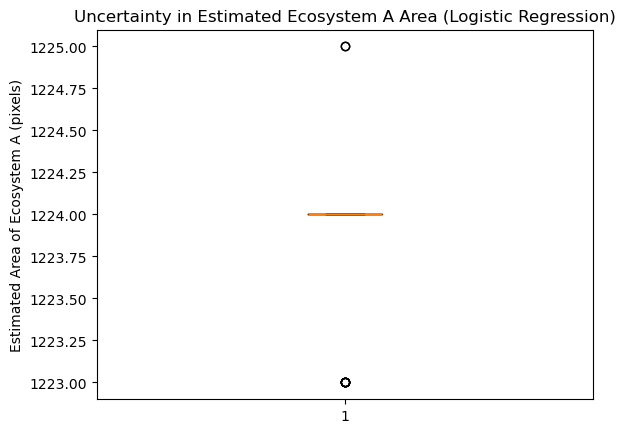

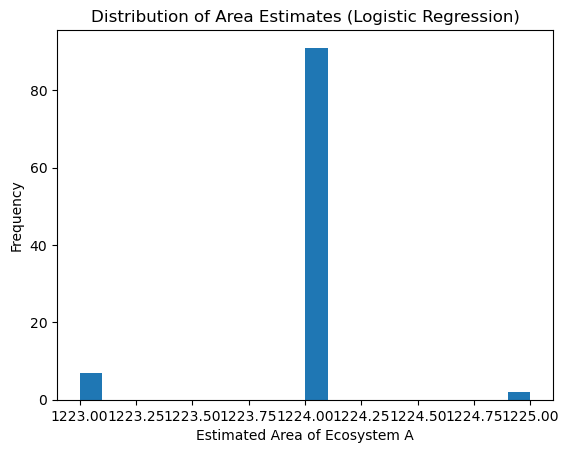

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# -----------------------------
# 1. Setup
# -----------------------------
n = 100  # 100x100 pixels

x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

# -----------------------------
# 2. True ecosystem (ground truth)
# -----------------------------
distance = np.sqrt(X**2 + Y**2)
region_A = distance < 0.4  # True ecosystem A

# -----------------------------
# 3. Environmental features (reproducible)
# -----------------------------
# Fix the seed here to generate reproducible features
np.random.seed(42)

temperature = np.where(
    region_A,
    np.random.normal(30, 2, (n, n)),
    np.random.normal(20, 2, (n, n))
)

humidity = np.where(
    region_A,
    np.random.normal(70, 5, (n, n)),
    np.random.normal(40, 5, (n, n))
)

light_intensity = np.where(
    region_A,
    np.random.normal(800, 50, (n, n)),
    np.random.normal(400, 50, (n, n))
)

# -----------------------------
# 4. Feature matrix & labels
# -----------------------------
X_features = np.column_stack((
    temperature.ravel(),
    humidity.ravel(),
    light_intensity.ravel()
))
y_true = region_A.astype(int).ravel()

# -----------------------------
# 5. Train Logistic Regression
# -----------------------------
lr_clf = LogisticRegression(max_iter=500)
lr_clf.fit(X_features, y_true)

# -----------------------------
# 6. Pixel-wise probabilities
# -----------------------------
probabilities = lr_clf.predict_proba(X_features)[:, 1]
probability_map = probabilities.reshape(n, n)

# -----------------------------
# 7. Monte Carlo simulations (uncertainty)
# -----------------------------
num_simulations = 100
area_estimates = []

# Don't set a seed here, so MC is stochastic each run
for _ in range(num_simulations):
    # Sample 1/0 for each pixel based on classifier probability
    sampled_ecosystem = np.random.binomial(n=1, p=probabilities).reshape(n, n)
    area_estimates.append(sampled_ecosystem.sum())

area_estimates = np.array(area_estimates)

# -----------------------------
# 8. Results
# -----------------------------
true_area = region_A.sum()

print("True area (pixels):", true_area)
print("Mean estimated area:", area_estimates.mean())
print("Standard deviation (uncertainty):", area_estimates.std())

# -----------------------------
# 9. Visualizations
# -----------------------------
# Boxplot
plt.figure()
plt.boxplot(area_estimates)
plt.ylabel("Estimated Area of Ecosystem A (pixels)")
plt.title("Uncertainty in Estimated Ecosystem A Area (Logistic Regression)")
plt.show()

# Histogram
plt.figure()
plt.hist(area_estimates, bins=20)
plt.xlabel("Estimated Area of Ecosystem A")
plt.ylabel("Frequency")
plt.title("Distribution of Area Estimates (Logistic Regression)")
plt.show()



True area (pixels): 1224
Mean estimated area: 1224.06
Standard deviation (uncertainty): 0.9981983770774223


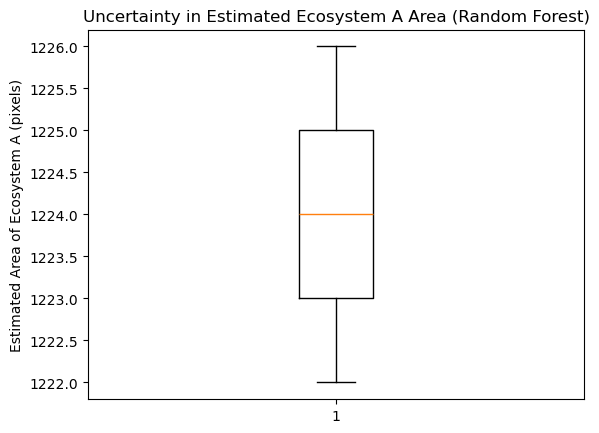

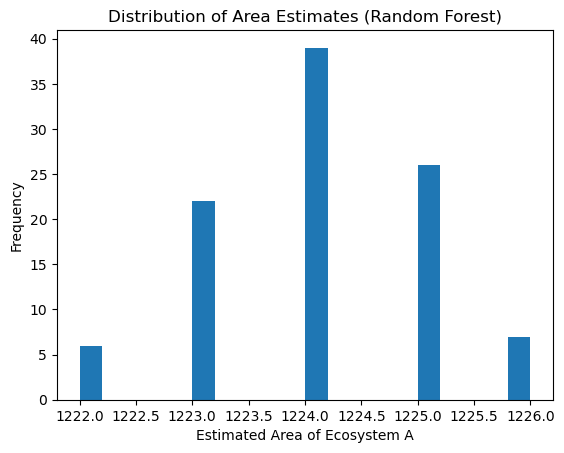

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Setup
# -----------------------------
n = 100  # 100x100 pixels

x = np.linspace(-1, 1, n)
y = np.linspace(-1, 1, n)
X, Y = np.meshgrid(x, y)

# -----------------------------
# 2. True ecosystem (ground truth)
# -----------------------------
distance = np.sqrt(X**2 + Y**2)
region_A = distance < 0.4  # True ecosystem A

# -----------------------------
# 3. Environmental features
# -----------------------------
temperature = np.where(
    region_A,
    np.random.normal(30, 2, (n, n)),
    np.random.normal(20, 2, (n, n))
)

humidity = np.where(
    region_A,
    np.random.normal(70, 5, (n, n)),
    np.random.normal(40, 5, (n, n))
)

light_intensity = np.where(
    region_A,
    np.random.normal(800, 50, (n, n)),
    np.random.normal(400, 50, (n, n))
)

# -----------------------------
# 4. Feature matrix & labels
# -----------------------------
X_features = np.column_stack((
    temperature.ravel(),
    humidity.ravel(),
    light_intensity.ravel()
))

y_true = region_A.astype(int).ravel()

# -----------------------------
# 5. Train Random Forest classifier
# -----------------------------
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None
)
rf_clf.fit(X_features, y_true)

# -----------------------------
# 6. Pixel-wise probabilities
# -----------------------------
probabilities = rf_clf.predict_proba(X_features)[:, 1]
probability_map = probabilities.reshape(n, n)

# -----------------------------
# 7. Monte Carlo simulations
# -----------------------------
num_simulations = 100
area_estimates = []

for _ in range(num_simulations):
    sampled_ecosystem = np.random.binomial(n=1, p=probabilities).reshape(n, n)
    area_estimates.append(sampled_ecosystem.sum())

area_estimates = np.array(area_estimates)

# -----------------------------
# 8. Results
# -----------------------------
true_area = region_A.sum()

print("True area (pixels):", true_area)
print("Mean estimated area:", area_estimates.mean())
print("Standard deviation (uncertainty):", area_estimates.std())

# -----------------------------
# 9. Visualizations
# -----------------------------
# Boxplot
plt.figure()
plt.boxplot(area_estimates)
plt.ylabel("Estimated Area of Ecosystem A (pixels)")
plt.title("Uncertainty in Estimated Ecosystem A Area (Random Forest)")
plt.show()

# Histogram
plt.figure()
plt.hist(area_estimates, bins=20)
plt.xlabel("Estimated Area of Ecosystem A")
plt.ylabel("Frequency")
plt.title("Distribution of Area Estimates (Random Forest)")
plt.show()
